# **WALK LOGGER**

In [1]:
import sys 
sys.path.append(r'C:\Users\tiffa\Documents\Walk-Logger')
import gpxpy
import pandas as pd
from src.parser import parse_gpx, get_metadata

In [2]:
filepath = r'C:\Users\tiffa\Documents\Walk-Logger\data\uploads\Morning_Walk.gpx'
df = parse_gpx(filepath)
name = get_metadata(filepath)

In [3]:
print(f"Walk name: {name}")
print(f"Points loaded: {len(df)}")
print(df.head())

Walk name: Morning Walk
Points loaded: 7128
         lat       lon  elevation                      time
0  51.477586 -0.277367        4.0 2026-06-13 09:27:06+00:00
1  51.477633 -0.277304        4.0 2026-06-13 09:27:07+00:00
2  51.477634 -0.277294        4.0 2026-06-13 09:27:08+00:00
3  51.477635 -0.277284        4.0 2026-06-13 09:27:09+00:00
4  51.477636 -0.277274        4.0 2026-06-13 09:27:10+00:00


In [4]:
print(f"Start time: {df['time'].min()}")
print(f"End time: {df['time'].max()}")
# Prints data to 1 and 4 decimal places
print(f"Elevation range: {df['elevation'].min():.1f}m to {df['elevation'].max():.1f}m")
print(f"Lat range: {df['lat'].min():.4f} to {df['lat'].max():.4f}")

Start time: 2026-06-13 09:27:06+00:00
End time: 2026-06-13 11:26:34+00:00
Elevation range: 3.5m to 5.5m
Lat range: 51.4702 to 51.4890


In [5]:
from src.stats import get_stats, haversine

In [6]:
stats = get_stats(df)
for key, value in stats.items():
    print(f"{key}: {value}")

distance_km: 10.75
duration: 1h 59m
pace: 11:06 min/km
elevation: 13.7
total_points: 7128


In [7]:
distances = [0]
for i in range(1, len(df)):
    d = haversine(df['lat'].iloc[i-1], df['lon'].iloc[i-1], df['lat'].iloc[i], df['lon'].iloc[i])
    distances.append(distances[-1] + d)

df['distance_km'] = distances
print(df[['lat', 'lon', 'elevation', 'distance_km']].head())

         lat       lon  elevation  distance_km
0  51.477586 -0.277367        4.0     0.000000
1  51.477633 -0.277304        4.0     0.007193
2  51.477634 -0.277294        4.0     0.007934
3  51.477635 -0.277284        4.0     0.008675
4  51.477636 -0.277274        4.0     0.009416


In [8]:
from src.database import initialise_db, save_walk, get_walks
initialise_db()
print("Database created successfully")

Database created successfully


In [9]:
# Extracts date from the timestamp
date = df['time'].iloc[0].strftime('%Y-%m-%d') 
save_walk(name=name, date=date, stats=stats, filename='Morning_Walk.gpx')

Saved walk: Morning Walk


In [10]:
# Debugging
walks = get_walks()
for walk in walks:
    print(f"{walk.date} | {walk.name} | {walk.distance_km}km | {walk.duration} | {walk.pace}")

2026-06-13 | Morning Walk | 10.75km | 1h 59m | 11:06 min/km
2026-06-13 | Morning Walk | 10.75km | 1h 59m | 11:06 min/km


In [11]:
from src.maps import create_map, create_heatmap, save_map
route_map = create_map(df, name)
save_map(route_map, r'C:\Users\tiffa\Documents\Walk-Logger\templates\route_map.html')

Map saved to C:\Users\tiffa\Documents\Walk-Logger\templates\route_map.html


In [12]:
# Opening the route map HTML file
import webbrowser
webbrowser.open(r'C:\Users\tiffa\Documents\Walk-Logger\templates\route_map.html')

True

In [13]:
# Generating the heatmap
all_coordinates = list(zip(df['lat'], df['lon']))
heatmap = create_heatmap(all_coordinates)
save_map(heatmap, r'C:\Users\tiffa\Documents\Walk-Logger\templates\heatmap.html')
webbrowser.open(r'C:\Users\tiffa\Documents\Walk-Logger\templates\heatmap.html')

Map saved to C:\Users\tiffa\Documents\Walk-Logger\templates\heatmap.html


True

In [15]:
# Getting date and adding week column (starts on monday)
df['date'] = df['time'].dt.date
df['week'] = pd.to_datetime(df['time'].dt.to_period('W-MON').apply(lambda r: r.start_time))

# Getting total disgtance per week
weekly = df.groupby('week')['distance_km'].max().reset_index()
print(weekly)

C:\Users\tiffa\AppData\Local\Temp\ipykernel_1468\1695412679.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = pd.to_datetime(df['time'].dt.to_period('W-MON').apply(lambda r: r.start_time))


        week  distance_km
0 2026-06-09    10.752312


In [16]:
import plotly.express as px

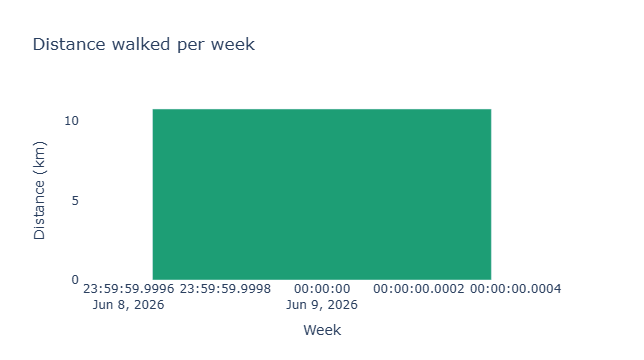

Weekly distance chart saved


In [17]:
# Building chart and saving it to folder
figure = px.bar(weekly, x = 'week', y = 'distance_km', title = 'Distance walked per week', labels = {'week': 'Week', 'distance_km': 'Distance (km)'}, color_discrete_sequence = ['#1D9E75'])
figure.update_layout(plot_bgcolor = 'white', showlegend = False, hovermode = 'x unified', bargap = 0.3)
figure.show()

figure.write_html(r'C:\Users\tiffa\Documents\Walk-Logger\templates\weekly_distance.html')
print("Weekly distance chart saved")